# Section - XGBoost Model

TRY NEW MODEL - APRIL 2026 <br>
Updated on  : 21/04/2026 

# 1. Load Function

In [ ]:
import pandas as pd
import numpy as np
import re
import pickle
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# 2. Load Files

In [14]:
# ============================================================
# 📂 LOAD & COMBINE ALL PROJECT FILES
# ============================================================
print("=" * 100)
print("📊 LOADING DATA")
print("=" * 100)

folder_path = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\dummy_data"

dfs = []
for file in os.listdir(folder_path):
    if file.endswith(".xlsx"):
        path = os.path.join(folder_path, file)
        try:
            df_temp = pd.read_excel(path)
            df_temp.columns = df_temp.columns.str.upper()
            dfs.append(df_temp)
            print(f"   ✅ Loaded: {file} — {len(df_temp)} rows")
        except Exception as e:
            print(f"   ⚠ Skipped ({e}): {file}")

if not dfs:
    raise ValueError("No Excel files found or loaded from the specified folder.")

df = pd.concat(dfs, ignore_index=True)

print(f"\n   Total records: {len(df)}")
print(f"   Columns: {', '.join(df.columns)}")
print(f"\n📋 Preview:\n{df.head(10)}")


📊 LOADING DATA
   ✅ Loaded: Oiltek_A1706.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9991.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9992.xlsx — 93 rows
   ✅ Loaded: Oiltek_A9993.xlsx — 128 rows
   ✅ Loaded: Oiltek_A9994.xlsx — 108 rows
   ✅ Loaded: Oiltek_A9995.xlsx — 108 rows
   ✅ Loaded: UGS_A2027.xlsx — 328 rows
   ✅ Loaded: UGS_A8881.xlsx — 86 rows
   ✅ Loaded: UGS_A8882.xlsx — 115 rows
   ✅ Loaded: UGS_A8883.xlsx — 115 rows
   ✅ Loaded: UGS_A8884.xlsx — 115 rows
   ✅ Loaded: UGS_A8885.xlsx — 116 rows

   Total records: 1568
   Columns: CUSTOMER, PROJECT, SECTION, CLUSTER, DEVICE_ID

📋 Preview:
  CUSTOMER PROJECT    SECTION    CLUSTER DEVICE_ID
0   OILTEK   A1706  SECTION 1  CLUSTER 1      A500
1   OILTEK   A1706  SECTION 1  CLUSTER 1     HT500
2   OILTEK   A1706  SECTION 1  CLUSTER 1    PT500A
3   OILTEK   A1706  SECTION 1  CLUSTER 1    PV500B
4   OILTEK   A1706  SECTION 1  CLUSTER 1     TE500
5   OILTEK   A1706  SECTION 2  CLUSTER 1    HLA600
6   OILTEK   A1706  SECTION 2  CLUSTER 1     DV60

# 3. Feature Engineering

In [15]:

# ============================================================
# 🔧 FEATURE ENGINEERING
# ============================================================
print("\n" + "=" * 100)
print("🔧 FEATURE ENGINEERING (PROJECT-AWARE)")
print("=" * 100)

def extract_numeric_block(device_id):
    """Extract the first continuous numeric block. e.g. HLA600 → 600, PT500A → 500"""
    match = re.search(r'\d+', str(device_id))
    return int(match.group()) if match else -1

def extract_prefix(device_id):
    """Extract alphabetic prefix before numeric block. e.g. HLA600 → HLA, A500 → A"""
    match = re.match(r'^([A-Za-z]+)', str(device_id))
    return match.group(1).upper() if match else ''

def extract_suffix_letters(device_id):
    """Extract trailing letters after numeric block. e.g. PT500A → A, A500 → ''"""
    match = re.search(r'\d+([A-Za-z]*)$', str(device_id))
    return match.group(1).upper() if match else ''

def extract_suffix_full(device_id):
    """Extract everything after numeric block (letters + digits + symbols). e.g. PT500A1.2 → A1.2"""
    match = re.search(r'\d+(.*)$', str(device_id))
    return match.group(1) if match else ''

def extract_section_num(section_str):
    """e.g. 'SECTION 1' → 1"""
    digits = ''.join(c for c in str(section_str) if c.isdigit())
    return int(digits) if digits else 0

def extract_cluster_num(cluster_str):
    """e.g. 'CLUSTER 1' → 1"""
    digits = ''.join(c for c in str(cluster_str) if c.isdigit())
    return int(digits) if digits else 0


# ── BASIC DEVICE ID FEATURES ────────────────────────────────
df['numeric_block']     = df['DEVICE_ID'].apply(extract_numeric_block)
df['device_prefix']     = df['DEVICE_ID'].apply(extract_prefix)
df['device_suffix_letter']  = df['DEVICE_ID'].apply(extract_suffix_letters)  
df['suffix_full']       = df['DEVICE_ID'].apply(extract_suffix_full)     
df['prefix_length']     = df['device_prefix'].str.len()
df['device_id_length']  = df['DEVICE_ID'].astype(str).str.len()
df['has_suffix_letter'] = (df['device_suffix_letter'] != '').astype(int)
df['has_numeric']       = (df['numeric_block'] != -1).astype(int)

# ──  SUFFIX FEATURES ────────────────────────────
print("\n   Creating advanced suffix features...")

# 1. Full suffix analysis (includes letters, digits, decimals)
df['suffix_length']             = df['suffix_full'].astype(str).str.len()
df['suffix_has_digit']          = df['suffix_full'].astype(str).str.contains(r'\d', regex=True).astype(int)
df['suffix_has_letter']         = df['suffix_full'].astype(str).str.contains(r'[A-Za-z]', regex=True).astype(int)
df['suffix_has_decimal']        = df['suffix_full'].astype(str).str.contains(r'\.', regex=True).astype(int)
df['suffix_digit_count']        = df['suffix_full'].astype(str).str.count(r'\d')
df['suffix_letter_count']       = df['suffix_full'].astype(str).str.count(r'[A-Za-z]')
df['suffix_starts_with_digit']  = df['suffix_full'].astype(str).str[0].str.isdigit().fillna(0).astype(int)

# 2. Suffix character analysis (KEY for customer-specific patterns)
df['suffix_last_char']            = df['suffix_full'].astype(str).str[-1]
df['suffix_last_char_is_letter']  = df['suffix_last_char'].str.isalpha().fillna(0).astype(int)
df['suffix_last_char_is_digit']   = df['suffix_last_char'].str.isdigit().fillna(0).astype(int)

# 3. Equipment ID features (DEVICE_ID analysis)
df['equip_id_length']       = df['DEVICE_ID'].astype(str).str.len()
df['equip_id_digit_count']  = df['DEVICE_ID'].astype(str).str.count(r'\d')
df['equip_id_letter_count'] = df['DEVICE_ID'].astype(str).str.count(r'[A-Za-z]')

print("   ✅ Advanced suffix features created")

# ── KEY FEATURE: relative rank of numeric block within project ──────────────

df['numeric_block_rank_in_project'] = (
    df.groupby(['CUSTOMER', 'PROJECT'])['numeric_block']
    .transform(lambda x: pd.cut(x, bins=len(x.unique()), labels=False, duplicates='drop') + 1
               if x.nunique() > 1 else 1)
)

# Simpler and more robust: rank unique numeric blocks per project
def assign_block_rank(group):
    unique_blocks = sorted(group['numeric_block'].unique())
    block_to_rank = {b: i + 1 for i, b in enumerate(unique_blocks)}
    return group['numeric_block'].map(block_to_rank)

df['numeric_block_rank'] = df.groupby(['CUSTOMER', 'PROJECT'], group_keys=False).apply(assign_block_rank)

print("   ✅ numeric_block_rank: rank of numeric block within project (1=lowest)")
print(f"\n   Sample feature preview:")
print(df[['CUSTOMER', 'PROJECT', 'DEVICE_ID', 'numeric_block', 'suffix_full', 
          'suffix_length', 'suffix_last_char', 'numeric_block_rank', 'SECTION']].head(15))




🔧 FEATURE ENGINEERING (PROJECT-AWARE)

   Creating advanced suffix features...
   ✅ Advanced suffix features created
   ✅ numeric_block_rank: rank of numeric block within project (1=lowest)

   Sample feature preview:
   CUSTOMER PROJECT DEVICE_ID  numeric_block suffix_full  suffix_length  \
0    OILTEK   A1706      A500            500                          0   
1    OILTEK   A1706     HT500            500                          0   
2    OILTEK   A1706    PT500A            500           A              1   
3    OILTEK   A1706    PV500B            500           B              1   
4    OILTEK   A1706     TE500            500                          0   
5    OILTEK   A1706    HLA600            600                          0   
6    OILTEK   A1706     DV601            601                          0   
7    OILTEK   A1706     FB601            601                          0   
8    OILTEK   A1706    HLA601            601                          0   
9    OILTEK   A1706    LLA601  

# 4. Label Encoding

In [ ]:

# ============================================================
# 🔤 ENCODE CATEGORICAL VARIABLES
# ============================================================
print("\n" + "=" * 100)
print("🔤 ENCODING CATEGORICAL VARIABLES")
print("=" * 100)

le_customer       = LabelEncoder()
le_project        = LabelEncoder()
le_prefix         = LabelEncoder()
le_suffix_letter  = LabelEncoder()
le_suffix_last    = LabelEncoder()  
le_section        = LabelEncoder()
le_cluster        = LabelEncoder()

df['customer_enc']         = le_customer.fit_transform(df['CUSTOMER'])      ### problem where the model is not become custoemr specific
df['project_enc']          = le_project.fit_transform(df['PROJECT'])
df['prefix_enc']           = le_prefix.fit_transform(df['device_prefix'])
df['suffix_letter_enc']    = le_suffix_letter.fit_transform(df['device_suffix_letter'])
df['suffix_last_char_enc'] = le_suffix_last.fit_transform(df['suffix_last_char'])  # NEW
df['section_enc']          = le_section.fit_transform(df['SECTION'])
df['cluster_enc']          = le_cluster.fit_transform(df['CLUSTER'])

print(f"   Section classes: {list(le_section.classes_)}")
print(f"   Cluster classes: {list(le_cluster.classes_)}")


🔤 ENCODING CATEGORICAL VARIABLES
   Section classes: ['SECTION 1', 'SECTION 2', 'SECTION 3', 'SECTION 4', 'SECTION 5', 'SECTION 6']
   Cluster classes: ['CLUSTER 1', 'CLUSTER 2', 'CLUSTER 3', 'CLUSTER 4', 'CLUSTER 5', 'CLUSTER 6', 'CLUSTER 7', 'CLUSTER 8', 'CLUSTER 9']


# 5. Features & Targets

In [17]:

# ============================================================
# 🎯 FEATURES & TARGETS
# ============================================================
feature_columns = [
    'DEVICE_ID',
    # Original features
    'customer_enc',
    'project_enc',
    'numeric_block',
    'numeric_block_rank',
    'prefix_enc',
    'suffix_letter_enc',
    'prefix_length',
    'device_id_length',
    'has_suffix_letter',
    'has_numeric',
    
    # NEW: Advanced suffix features
    'suffix_length',
    'suffix_has_digit',
    'suffix_has_letter',
    'suffix_has_decimal',
    'suffix_digit_count',
    'suffix_letter_count',
    'suffix_starts_with_digit',
    'suffix_last_char_enc',
    'suffix_last_char_is_letter',
    'suffix_last_char_is_digit',
    
    # NEW: Equipment ID features
    'equip_id_length',
    'equip_id_digit_count',
    'equip_id_letter_count',
]

X = df[feature_columns]
y_section = df['section_enc']
y_cluster = df['cluster_enc']

print(f"\n   Total features: {len(feature_columns)}")
print(f"   Feature list: {feature_columns}")



   Total features: 24
   Feature list: ['DEVICE_ID', 'customer_enc', 'project_enc', 'numeric_block', 'numeric_block_rank', 'prefix_enc', 'suffix_letter_enc', 'prefix_length', 'device_id_length', 'has_suffix_letter', 'has_numeric', 'suffix_length', 'suffix_has_digit', 'suffix_has_letter', 'suffix_has_decimal', 'suffix_digit_count', 'suffix_letter_count', 'suffix_starts_with_digit', 'suffix_last_char_enc', 'suffix_last_char_is_letter', 'suffix_last_char_is_digit', 'equip_id_length', 'equip_id_digit_count', 'equip_id_letter_count']


In [18]:
print(df.columns)
print(X.columns)


Index(['CUSTOMER', 'PROJECT', 'SECTION', 'CLUSTER', 'DEVICE_ID',
       'numeric_block', 'device_prefix', 'device_suffix_letter', 'suffix_full',
       'prefix_length', 'device_id_length', 'has_suffix_letter', 'has_numeric',
       'suffix_length', 'suffix_has_digit', 'suffix_has_letter',
       'suffix_has_decimal', 'suffix_digit_count', 'suffix_letter_count',
       'suffix_starts_with_digit', 'suffix_last_char',
       'suffix_last_char_is_letter', 'suffix_last_char_is_digit',
       'equip_id_length', 'equip_id_digit_count', 'equip_id_letter_count',
       'numeric_block_rank_in_project', 'numeric_block_rank', 'customer_enc',
       'project_enc', 'prefix_enc', 'suffix_letter_enc',
       'suffix_last_char_enc', 'section_enc', 'cluster_enc'],
      dtype='object')
Index(['DEVICE_ID', 'customer_enc', 'project_enc', 'numeric_block',
       'numeric_block_rank', 'prefix_enc', 'suffix_letter_enc',
       'prefix_length', 'device_id_length', 'has_suffix_letter', 'has_numeric',
       's

# 6. Chain model (train, val, test)

In [20]:
# ============================================================
# ✂️ TRAIN / VAL / TEST SPLIT (DataFrame-based)
# ============================================================
print("\n" + "=" * 100)
print("✂️  SPLITTING DATA")
print("=" * 100)

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


def safe_split_df(df, label_col, test_size=0.15, val_size=0.176, max_attempts=100):
    y = df[label_col]
    all_classes = set(np.unique(y))

    for attempt in range(max_attempts):
        idx_tmp, idx_test = train_test_split(
            df.index,
            test_size=test_size,
            random_state=42 + attempt,
            stratify=y,
            shuffle=True
        )

        idx_train, idx_val = train_test_split(
            idx_tmp,
            test_size=val_size,
            random_state=42 + attempt,
            stratify=y.loc[idx_tmp],
            shuffle=True
        )

        if set(np.unique(y.loc[idx_train])) == all_classes:
            print(f"   ✅ Valid split on attempt {attempt + 1}")
            break
    else:
        print("   ⚠ Using last split (not all classes in train)")

    train_df = df.loc[idx_train].copy().reset_index(drop=False)
    val_df   = df.loc[idx_val].copy().reset_index(drop=False)
    test_df  = df.loc[idx_test].copy().reset_index(drop=False)

    train_df["_split"] = "train"
    val_df["_split"]   = "val"
    test_df["_split"]  = "test"

    return train_df, val_df, test_df


# ✅ Build full DataFrame
full_df = X.copy()
full_df["y_section"] = y_section
full_df["y_cluster"] = y_cluster

# ✅ Split
train_df, val_df, test_df = safe_split_df(full_df, label_col="y_section")

# ✅ Feature cols
feature_cols = X.columns.tolist()

# ✅ Extract features
def extract_features(df, cols):
    X_out = df[cols].apply(pd.to_numeric, errors='coerce')
    bad   = X_out.dtypes[X_out.dtypes == 'object'].index.tolist()
    if bad:
        print(f"   ⚠ Dropping non-numeric columns: {bad}")
        X_out = X_out.drop(columns=bad)
    X_out = X_out.fillna(0)
    return X_out

X_train = extract_features(train_df, feature_cols)
X_val   = extract_features(val_df,   feature_cols)
X_test  = extract_features(test_df,  feature_cols)

y_sec_train = train_df["y_section"]
y_sec_val   = val_df["y_section"]
y_sec_test  = test_df["y_section"]

y_clu_train = train_df["y_cluster"]
y_clu_val   = val_df["y_cluster"]
y_clu_test  = test_df["y_cluster"]

# ✅ Diagnostics
print(f"\n   Train : {len(train_df):,} rows")
print(f"   Val   : {len(val_df):,} rows")
print(f"   Test  : {len(test_df):,} rows")
print(f"   Feature shape (train) : {X_train.shape}")
print(f"   Dtype breakdown       :\n{X_train.dtypes.value_counts()}")
print(f"\n   Sample train_df (with origin index):")
print(train_df[["index", "y_section", "y_cluster", "_split"]].head(5))


# ============================================================
# 🚀 STAGE 1 — TRAIN SECTION MODEL
# ============================================================
print("\n" + "=" * 100)
print("🚀 STAGE 1 — TRAINING SECTION MODEL")
print("=" * 100)

def build_model(n_classes):
    return xgb.XGBClassifier(
        objective        = 'multi:softprob',
        num_class        = n_classes,
        max_depth        = 6,
        learning_rate    = 0.05,
        n_estimators     = 300,
        min_child_weight = 1,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        gamma            = 0.1,
        random_state     = 42,
        eval_metric      = 'mlogloss',
    )

# ✅ Train section model on original features
model_section = build_model(len(le_section.classes_))
model_section.fit(
    X_train, y_sec_train,
    eval_set=[(X_train, y_sec_train), (X_val, y_sec_val)],
    verbose=False
)

# ✅ Predict section on ALL splits — needed to chain into cluster model
y_sec_pred_train = model_section.predict(X_train)
y_sec_pred_val   = model_section.predict(X_val)
y_sec_pred_test  = model_section.predict(X_test)

print(f"\n   🎯 Section Test Accuracy: {accuracy_score(y_sec_test, y_sec_pred_test):.2%}")
print(classification_report(
    y_sec_test, y_sec_pred_test,
    target_names=le_section.classes_,
    zero_division=0
))


# ============================================================
# 🔗 CHAIN — INJECT SECTION PREDICTION AS FEATURE
# ============================================================
print("\n" + "=" * 100)
print("🔗 CHAINING — INJECTING SECTION PREDICTION INTO CLUSTER FEATURES")
print("=" * 100)

# ✅ Add predicted section as an extra input feature for cluster model
X_train_chained = X_train.copy()
X_val_chained   = X_val.copy()
X_test_chained  = X_test.copy()

X_train_chained["predicted_section"] = y_sec_pred_train
X_val_chained["predicted_section"]   = y_sec_pred_val
X_test_chained["predicted_section"]  = y_sec_pred_test

print(f"   ✅ Feature shape after chaining (train) : {X_train_chained.shape}")
print(f"   ✅ New feature added                    : 'predicted_section'")


# ============================================================
# 🚀 STAGE 2 — TRAIN CLUSTER MODEL (Section-Aware)
# ============================================================
print("\n" + "=" * 100)
print("🚀 STAGE 2 — TRAINING CLUSTER MODEL (Chained — Section-Aware)")
print("=" * 100)

# ✅ Cluster model now receives original features + predicted section
model_cluster = build_model(len(le_cluster.classes_))
model_cluster.fit(
    X_train_chained, y_clu_train,
    eval_set=[(X_train_chained, y_clu_train), (X_val_chained, y_clu_val)],
    verbose=False
)

y_clu_pred = model_cluster.predict(X_test_chained)

print(f"\n   🎯 Cluster Test Accuracy: {accuracy_score(y_clu_test, y_clu_pred):.2%}")
print(classification_report(
    y_clu_test, y_clu_pred,
    target_names=le_cluster.classes_,
    zero_division=0
))


# ============================================================
# 📋 CHAIN SUMMARY
# ============================================================
print("\n" + "=" * 100)
print("📋 CHAINED MODEL SUMMARY")
print("=" * 100)
print(f"   Stage 1 — Section Model  : {accuracy_score(y_sec_test, y_sec_pred_test):.2%} accuracy")
print(f"   Stage 2 — Cluster Model  : {accuracy_score(y_clu_test, y_clu_pred):.2%} accuracy")
print(f"\n   🔗 Chain flow:")
print(f"      X_features")
print(f"         └──→ [Section Model] ──→ predicted_section")
print(f"                                        │")
print(f"         X_features + predicted_section │")
print(f"         └──────────────────────────────┘")
print(f"                  └──→ [Cluster Model] ──→ predicted_cluster")


✂️  SPLITTING DATA
   ✅ Valid split on attempt 1

   Train : 1,097 rows
   Val   : 235 rows
   Test  : 236 rows
   Feature shape (train) : (1097, 24)
   Dtype breakdown       :
int64      23
float64     1
Name: count, dtype: int64

   Sample train_df (with origin index):
   index  y_section  y_cluster _split
0    858          0          8  train
1     63          3          3  train
2    392          2          3  train
3    710          0          0  train
4   1402          1          1  train

🚀 STAGE 1 — TRAINING SECTION MODEL

   🎯 Section Test Accuracy: 99.58%
              precision    recall  f1-score   support

   SECTION 1       1.00      0.99      0.99        71
   SECTION 2       1.00      1.00      1.00        54
   SECTION 3       0.98      1.00      0.99        46
   SECTION 4       1.00      1.00      1.00        23
   SECTION 5       1.00      1.00      1.00        38
   SECTION 6       1.00      1.00      1.00         4

    accuracy                           1.00    

# 7. Chain Model Output

In [21]:
# ============================================================
# 📋 RESULT DATAFRAME — CHAINED MODEL PREDICTIONS
# ============================================================

# ✅ TRAIN
train_df2 = train_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
train_df2["actual_section"]    = le_section.inverse_transform(train_df2["y_section"])
train_df2["actual_cluster"]    = le_cluster.inverse_transform(train_df2["y_cluster"])
train_df2["pred_section"]      = le_section.inverse_transform(y_sec_pred_train)
train_df2["pred_cluster"]      = le_cluster.inverse_transform(model_cluster.predict(X_train_chained))
train_df2["section_correct"]   = train_df2["actual_section"] == train_df2["pred_section"]
train_df2["cluster_correct"]   = train_df2["actual_cluster"] == train_df2["pred_cluster"]

# ✅ VAL
val_df2 = val_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
val_df2["actual_section"]      = le_section.inverse_transform(val_df2["y_section"])
val_df2["actual_cluster"]      = le_cluster.inverse_transform(val_df2["y_cluster"])
val_df2["pred_section"]        = le_section.inverse_transform(y_sec_pred_val)
val_df2["pred_cluster"]        = le_cluster.inverse_transform(model_cluster.predict(X_val_chained))
val_df2["section_correct"]     = val_df2["actual_section"] == val_df2["pred_section"]
val_df2["cluster_correct"]     = val_df2["actual_cluster"] == val_df2["pred_cluster"]

# ✅ TEST
test_df2 = test_df[["index", "DEVICE_ID", "y_section", "y_cluster", "_split"]].copy()
test_df2["actual_section"]     = le_section.inverse_transform(test_df2["y_section"])
test_df2["actual_cluster"]     = le_cluster.inverse_transform(test_df2["y_cluster"])
test_df2["pred_section"]       = le_section.inverse_transform(y_sec_pred_test)
test_df2["pred_cluster"]       = le_cluster.inverse_transform(y_clu_pred)
test_df2["section_correct"]    = test_df2["actual_section"] == test_df2["pred_section"]
test_df2["cluster_correct"]    = test_df2["actual_cluster"] == test_df2["pred_cluster"]

# ✅ COMBINE ALL SPLITS
full_result_df = pd.concat([train_df2, val_df2, test_df2], ignore_index=True)

# ✅ DIAGNOSTICS
print("\n" + "=" * 100)
print("📋 PREDICTION RESULT SUMMARY")
print("=" * 100)

for split_name, df_split in [("TRAIN", train_df2), ("VAL", val_df2), ("TEST", test_df2)]:
    sec_acc = df_split["section_correct"].mean()
    clu_acc = df_split["cluster_correct"].mean()
    print(f"\n   [{split_name}]")
    print(f"      Section Accuracy : {sec_acc:.2%}")
    print(f"      Cluster Accuracy : {clu_acc:.2%}")

print(f"\n   📊 Full result shape : {full_result_df.shape}")
print(f"\n   Sample output:")
print(full_result_df[["DEVICE_ID", "_split", "actual_section", "pred_section",
                        "actual_cluster", "pred_cluster",
                        "section_correct", "cluster_correct"]].head(10))


📋 PREDICTION RESULT SUMMARY

   [TRAIN]
      Section Accuracy : 100.00%
      Cluster Accuracy : 99.91%

   [VAL]
      Section Accuracy : 98.72%
      Cluster Accuracy : 99.15%

   [TEST]
      Section Accuracy : 99.58%
      Cluster Accuracy : 98.73%

   📊 Full result shape : (1568, 11)

   Sample output:
  DEVICE_ID _split actual_section pred_section actual_cluster pred_cluster  \
0   CPM1202  train      SECTION 1    SECTION 1      CLUSTER 9    CLUSTER 9   
1      V2.6  train      SECTION 4    SECTION 4      CLUSTER 4    CLUSTER 4   
2  PSL182.1  train      SECTION 3    SECTION 3      CLUSTER 4    CLUSTER 4   
3    LL0103  train      SECTION 1    SECTION 1      CLUSTER 1    CLUSTER 1   
4  V54CF4DA  train      SECTION 2    SECTION 2      CLUSTER 2    CLUSTER 2   
5    MF2101  train      SECTION 1    SECTION 1      CLUSTER 1    CLUSTER 1   
6    V09122  train      SECTION 3    SECTION 3      CLUSTER 7    CLUSTER 7   
7    SIC752  train      SECTION 5    SECTION 5      CLUSTER 1    

📊 Output Result (Test dataset) <br>

🔴 Case : Section ❌, Cluster ✅ <br>
🔵 Case : Section ✅, Cluster ❌

| DEVICE_ID | Actual Section | Predicted Section | Section Check | Actual Cluster | Predicted Cluster | Cluster Check |
| --------- | -------------- | ----------------- | ------------- | -------------- | ----------------- | ------------- |
| HT275     | SECTION 1      | SECTION 3         | ❌ False       | CLUSTER 1      | CLUSTER 1         | ✅ True        |
| CPM6311   | SECTION 1      | SECTION 1         | ✅ True        | CLUSTER 3      | CLUSTER 4         | ❌ False       |
| FIT151    | SECTION 3      | SECTION 3         | ✅ True        | CLUSTER 4      | CLUSTER 1         | ❌ False       |
| V29011    | SECTION 3      | SECTION 3         | ✅ True        | CLUSTER 7      | CLUSTER 4         | ❌ False       |




In [22]:
# ============================================================
# 📊 CHUNK 4 — FORMATTED RESULT TABLE (SECTION + CLUSTER CHECK)
# ============================================================

# ✅ Use TEST dataset (you can change to train/val if needed)
result_df = test_df[["DEVICE_ID"]].copy()

# --- SECTION ---
result_df["Actual Section"]    = le_section.inverse_transform(y_sec_test)
result_df["Predicted Section"] = le_section.inverse_transform(y_sec_pred_test)
result_df["Check Section"]     = result_df["Actual Section"] == result_df["Predicted Section"]

# --- CLUSTER ---
result_df["Actual Cluster"]    = le_cluster.inverse_transform(y_clu_test)
result_df["Predicted Cluster"] = le_cluster.inverse_transform(y_clu_pred)
result_df["Check Cluster"]     = result_df["Actual Cluster"] == result_df["Predicted Cluster"]

# --- Optional: Pretty display (emoji style like your screenshot) ---
def format_check(val):
    return "✅ True" if val else "❌ False"

result_df["Check Section"] = result_df["Check Section"].apply(format_check)
result_df["Check Cluster"] = result_df["Check Cluster"].apply(format_check)

# --- Display ---
print("\n📊 FORMATTED RESULT TABLE")
print("=" * 100)
print(result_df.head(10))

# # Optional: show all
# pd.set_option('display.max_rows', None)
# print(result_df)


📊 FORMATTED RESULT TABLE
  DEVICE_ID Actual Section Predicted Section Check Section Actual Cluster  \
0    PC1102      SECTION 1         SECTION 1        ✅ True      CLUSTER 9   
1    LL0401      SECTION 1         SECTION 1        ✅ True      CLUSTER 4   
2    VP582A      SECTION 5         SECTION 5        ✅ True      CLUSTER 1   
3    FIT101      SECTION 3         SECTION 3        ✅ True      CLUSTER 4   
4  PSL152.1      SECTION 3         SECTION 3        ✅ True      CLUSTER 4   
5    LL2103      SECTION 1         SECTION 1        ✅ True      CLUSTER 1   
6     V11.6      SECTION 4         SECTION 4        ✅ True      CLUSTER 2   
7    V45041      SECTION 3         SECTION 3        ✅ True      CLUSTER 4   
8  V11CR2DA      SECTION 2         SECTION 2        ✅ True      CLUSTER 7   
9      V8.8      SECTION 4         SECTION 4        ✅ True      CLUSTER 4   

  Predicted Cluster Check Cluster  
0         CLUSTER 9        ✅ True  
1         CLUSTER 4        ✅ True  
2         CLUSTER 

# 8 Feature Importance


⭐ FEATURE IMPORTANCE

   [SECTION]
                   feature  importance
         suffix_has_letter    0.250663
       suffix_letter_count    0.132002
      equip_id_digit_count    0.106324
             prefix_length    0.092844
        suffix_has_decimal    0.073768
     equip_id_letter_count    0.072218
              customer_enc    0.064082
          suffix_has_digit    0.042969
        suffix_digit_count    0.040340
             numeric_block    0.032252
        numeric_block_rank    0.017211
                prefix_enc    0.015067
             suffix_length    0.014056
               project_enc    0.011743
         suffix_letter_enc    0.011316
          device_id_length    0.006164
           equip_id_length    0.006102
         has_suffix_letter    0.006096
      suffix_last_char_enc    0.004784
                 DEVICE_ID    0.000000
               has_numeric    0.000000
  suffix_starts_with_digit    0.000000
suffix_last_char_is_letter    0.000000
 suffix_last_char_is_digit  

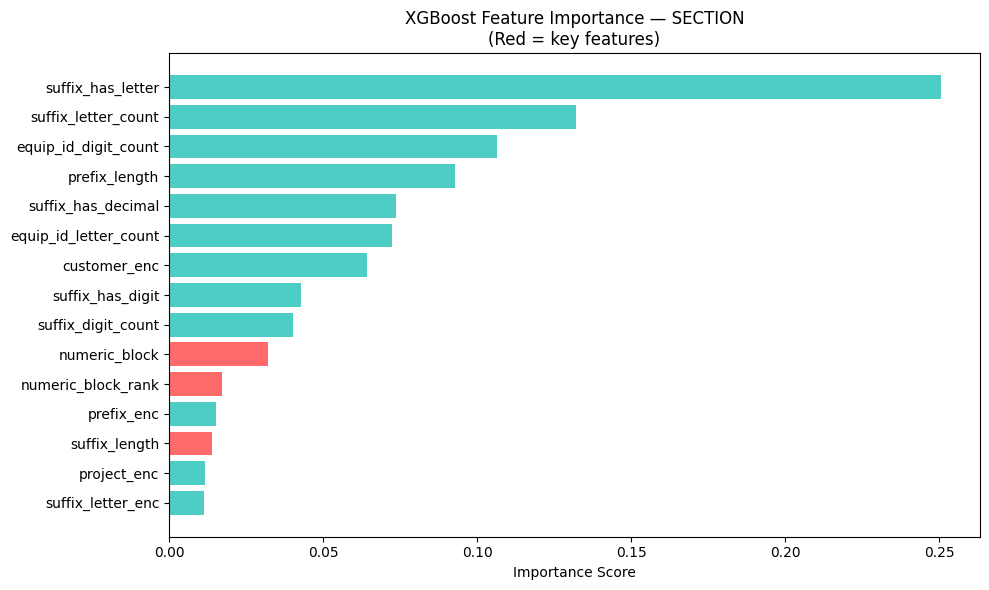


   [CLUSTER]
                   feature  importance
          suffix_has_digit    0.231820
              customer_enc    0.085087
             suffix_length    0.068795
 suffix_last_char_is_digit    0.066142
        suffix_has_decimal    0.061257
        suffix_digit_count    0.056995
         suffix_has_letter    0.049559
     equip_id_letter_count    0.045520
      equip_id_digit_count    0.044369
        numeric_block_rank    0.036429
         predicted_section    0.035996
      suffix_last_char_enc    0.032211
       suffix_letter_count    0.026280
             prefix_length    0.026228
             numeric_block    0.025085
                prefix_enc    0.021249
          device_id_length    0.020584
         has_suffix_letter    0.019204
         suffix_letter_enc    0.017632
           equip_id_length    0.016678
               project_enc    0.012881
                 DEVICE_ID    0.000000
               has_numeric    0.000000
suffix_last_char_is_letter    0.000000
  suffix_st

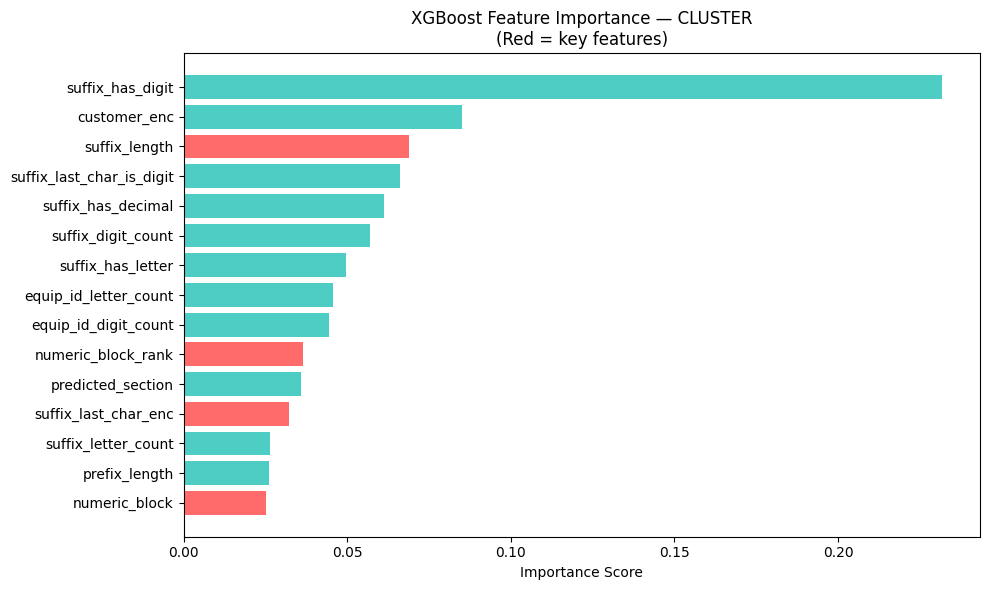

In [ ]:

# ============================================================
# ⭐ FEATURE IMPORTANCE (ROBUST VERSION)
# ============================================================
print("\n" + "=" * 100)
print("⭐ FEATURE IMPORTANCE")
print("=" * 100)

key_features = [
    'numeric_block_rank',
    'suffix_last_char_enc',
    'suffix_length',
    'numeric_block'
]

# ✅ Map model → correct feature set
model_feature_map = {
    "SECTION": (model_section, X_train),
    "CLUSTER": (model_cluster, X_train_chained)  # ⚠ important
}

for label, (model, X_used) in model_feature_map.items():

    # ✅ Safety check
    if len(X_used.columns) != len(model.feature_importances_):
        print(f"⚠ Skipping {label}: feature mismatch")
        print(f"   Features: {len(X_used.columns)}, Importances: {len(model.feature_importances_)}")
        continue

    fi = pd.DataFrame({
        'feature'   : X_used.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\n   [{label}]")
    print(fi.to_string(index=False))

    print(f"\n   Top 10 features for {label}:")
    print(fi.head(10).to_string(index=False))

    # 🎨 Color highlighting
    colors = [
        '#ff6b6b' if f in key_features else '#4ecdc4'
        for f in fi['feature']
    ]

    # 🎯 Plot only top 15 (cleaner)
    fi_top = fi.head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(fi_top['feature'], fi_top['importance'], color=colors[:len(fi_top)])
    plt.xlabel('Importance Score')
    plt.title(f'XGBoost Feature Importance — {label}\n(Red = key features)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()



# 9. Save Files

In [29]:
# ============================================================
# 💾 SAVE (FULL PIPELINE SAFE)
# ============================================================
print("\n" + "=" * 100)
print("💾 SAVING MODEL AND ENCODERS")
print("=" * 100)

SAVE_DIR = r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\model_config"
os.makedirs(SAVE_DIR, exist_ok=True)

# ✅ Save models
pickle.dump(model_section, open(os.path.join(SAVE_DIR, "model_section.pkl"), "wb"))
pickle.dump(model_cluster, open(os.path.join(SAVE_DIR, "model_cluster.pkl"), "wb"))

# ✅ Save EVERYTHING needed for inference
pipeline_config = {
    # Encoders
    'le_customer'    : le_customer,
    'le_project'     : le_project,
    'le_prefix'      : le_prefix,
    'le_suffix_lt'   : le_suffix_letter,
    'le_suffix_last' : le_suffix_last,
    'le_section'     : le_section,
    'le_cluster'     : le_cluster,
    'feature_columns': feature_columns,
    'section_features': list(X_train.columns),
    'cluster_features': list(X_train_chained.columns),
    'key_features': key_features,
}

pickle.dump(pipeline_config, open(os.path.join(SAVE_DIR, "pipeline_config.pkl"), "wb"))

print("   ✅ Saved: model_section.pkl, model_cluster.pkl, pipeline_config.pkl")


💾 SAVING MODEL AND ENCODERS
   ✅ Saved: model_section.pkl, model_cluster.pkl, pipeline_config.pkl


# --Finish --

### Save column [customer, project, device id, numeric block]

In [ ]:
df_oiltek_num = df[["CUSTOMER", "PROJECT", "SECTION", "CLUSTER", "DEVICE_ID", "numeric_block"]]
df_oiltek_num.to_pickle(
    r"C:\Users\sitisyaziyah\source\repos\DeviceCluster\1.training_model\model_config\df_oiltek_num.pkl"
)

### to do next? <br>
cross tabulation distribution for result testing actual vs prediction ✅ <br>
suggestion to create chain model (2 xgboost model work heirarchy) ✅ <br>
Check whether the model is run fix by customer? ❓❌ <br>
<br>
<br>
**PROBLEM** : Model develope is not customer-specific. ❗❗❗ [23/4/2026] <br>
**SOLUTION** : `SafeLabelEncoder` (new class, drop-in replacement) — wraps sklearn's `LabelEncoder` and adds an `__UNKNOWN__` class at fit time. <br>
<br>
2 model = 2 model train and predict separately
chain model = 2 model train and linked the section and cluster
